# EduPredict-XAI
## Step 13 — Feature Engineering

**Research Topic:** Student Performance Prediction Using Explainable AI  
**Student:** Payal Pramod Pawar  
**Program:** MCA Sem 3  
**Guide:** Mrs. Shaesta Mujawar  

### Objective

The objective of this notebook is to prepare meaningful predictive features from the cleaned student performance dataset.

The process includes:

- Loading the cleaned dataset
- Identifying the target variable
- Identifying numerical and categorical features
- Removing identifier and non-predictive columns
- Detecting constant and near-constant features
- Checking potential data leakage
- Studying feature relationships
- Creating meaningful derived features where appropriate
- Preparing the final feature-engineered dataset

The feature engineering process will be performed carefully to avoid data leakage.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Set paths
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

print("Project root:")
print(PROJECT_ROOT)

print("\nProcessed data folder:")
print(PROCESSED_DATA_PATH)

Project root:
d:\MCA Sem 3\RP\EduPredict-XAI

Processed data folder:
d:\MCA Sem 3\RP\EduPredict-XAI\data\processed


In [5]:
# Load the cleaned dataset
cleaned_path = PROCESSED_DATA_PATH / "main_student_performance_cleaned.csv"

df = pd.read_csv(cleaned_path)

print("Cleaned dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Cleaned dataset loaded successfully.
Shape: (1000, 12)


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,High School,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [6]:
# Check columns
print("Dataset columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset columns:

1. student_id
2. gender
3. study_time_hours
4. attendance_percent
5. sleep_hours
6. parental_education
7. internet_access
8. extracurricular_activities
9. part_time_job
10. previous_grade
11. final_exam_score
12. final_grade


In [7]:
# Set TARGET
TARGET = "final_exam_score"
print("Target:", TARGET)
print("Target exists:", TARGET in df.columns)

Target: final_exam_score
Target exists: True


In [8]:
# Separate features and target
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 11)
Target shape: (1000,)


In [9]:
# Identify numerical features
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical features:")
for feature in numeric_features:
    print("→", feature)

print("\nNumber of numerical features:", len(numeric_features))

Numerical features:
→ student_id
→ study_time_hours
→ attendance_percent
→ sleep_hours
→ previous_grade

Number of numerical features: 5


In [10]:
# Identify categorical features
categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Categorical features:")
for feature in categorical_features:
    print("→", feature)

print("\nNumber of categorical features:", len(categorical_features))

Categorical features:
→ gender
→ parental_education
→ internet_access
→ extracurricular_activities
→ part_time_job
→ final_grade

Number of categorical features: 6


In [12]:
# Find identifier columns
possible_id_columns = []

for col in X.columns:
    col_lower = col.lower()

    if (
        "id" in col_lower
        or "roll" in col_lower
        or "student_number" in col_lower
        or "registration" in col_lower
    ):
        possible_id_columns.append(col)

print("Possible identifier columns:")
for col in possible_id_columns:
    print("→", col)

for col in possible_id_columns:
    print(
        f"{col}: "
        f"{X[col].nunique()} unique values "
        f"out of {len(X)} records"
    )
ID_COLUMNS = ["student_id"]
X = X.drop(columns=ID_COLUMNS, errors="ignore")

print("Removed identifier columns:", ID_COLUMNS)
print("New feature shape:", X.shape)


Possible identifier columns:
Removed identifier columns: ['student_id']
New feature shape: (1000, 10)


In [13]:
# Check constant features
constant_features = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print("Constant features:")

if constant_features:
    for col in constant_features:
        print("→", col)
else:
    print("No constant features found.")

Constant features:
No constant features found.


In [16]:
# Check low-variance / near-constant features
feature_cardinality = pd.DataFrame({
    "Feature": X.columns,
    "Unique_Values": [
        X[col].nunique(dropna=False)
        for col in X.columns
    ],
    "Unique_Percentage": [
        X[col].nunique(dropna=False) / len(X) * 100
        for col in X.columns
    ]
})

display(
    feature_cardinality.sort_values(
        "Unique_Percentage"
    )
)

,Feature,Unique_Values,Unique_Percentage
0,gender,2,0.2
7,part_time_job,2,0.2
6,extracurricular_activities,2,0.2
5,internet_access,2,0.2
4,parental_education,4,0.4
9,final_grade,5,0.5
3,sleep_hours,65,6.5
1,study_time_hours,70,7.0
2,attendance_percent,327,32.7
8,previous_grade,434,43.4


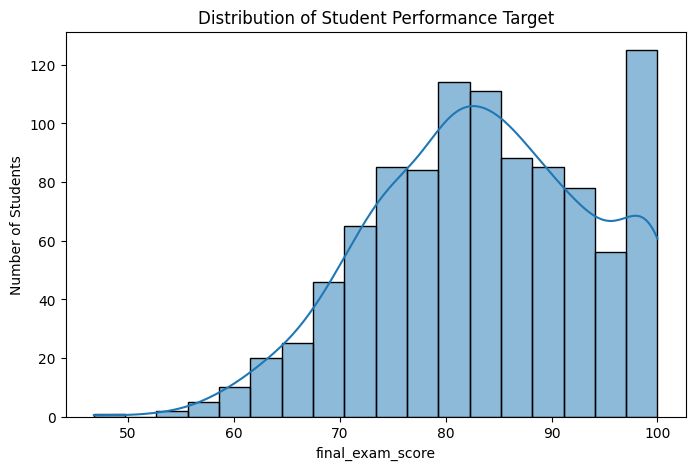

In [14]:
# Check target distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    y,
    kde=True
)

plt.title("Distribution of Student Performance Target")
plt.xlabel(TARGET)
plt.ylabel("Number of Students")

plt.show()

In [15]:
# Target statistics
print("Target statistics:")
display(
    y.describe()
)

Target statistics:


count    1000.000000
mean       83.543500
std        10.341333
min        46.800000
25%        76.075000
50%        83.800000
75%        91.525000
max       100.000000
Name: final_exam_score, dtype: float64

In [16]:
# Feature correlation
numeric_for_corr = X.select_dtypes(
    include=np.number
).copy()

numeric_for_corr[TARGET] = y

correlation_matrix = numeric_for_corr.corr()

display(correlation_matrix)

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
study_time_hours,1.000000,-0.043712,0.005594,-0.035700,0.567513
attendance_percent,-0.043712,1.000000,0.034089,-0.014310,0.261872
sleep_hours,0.005594,0.034089,1.000000,0.000943,0.147811
previous_grade,-0.035700,-0.014310,0.000943,1.000000,0.406327
final_exam_score,0.567513,0.261872,0.147811,0.406327,1.000000


In [17]:
# Correlation with target
target_correlation = (
    correlation_matrix[TARGET]
    .drop(TARGET)
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(target_correlation)

study_time_hours      0.567513
previous_grade        0.406327
attendance_percent    0.261872
sleep_hours           0.147811
Name: final_exam_score, dtype: float64

Strongest numerical feature: study_time_hours


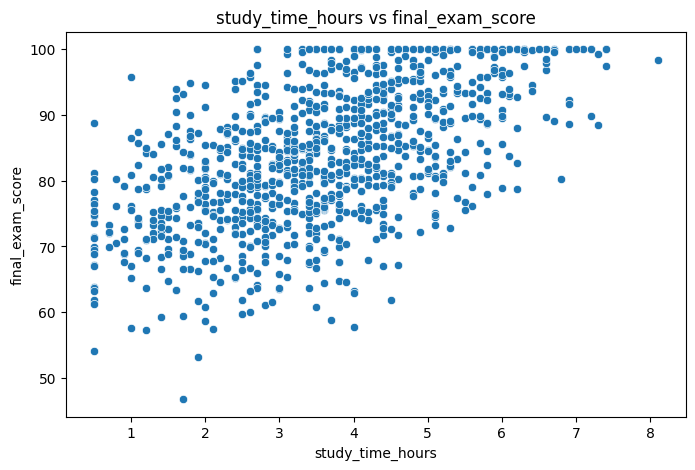

In [18]:
# Visualize numerical relationships
if len(target_correlation) > 0:

    best_feature = target_correlation.index[0]

    print("Strongest numerical feature:", best_feature)

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=best_feature,
        y=TARGET
    )

    plt.title(
        f"{best_feature} vs {TARGET}"
    )

    plt.xlabel(best_feature)
    plt.ylabel(TARGET)

    plt.show()

In [19]:
# Find suspicious feature names
leakage_keywords = [
    "final",
    "result",
    "score",
    "grade",
    "rank",
    "outcome",
    "performance",
    "exam"
]

possible_leakage = []

for col in X.columns:
    col_lower = col.lower()

    if any(
        keyword in col_lower
        for keyword in leakage_keywords
    ):
        possible_leakage.append(col)

print("Features requiring leakage review:")

for col in possible_leakage:
    print("→", col)

Features requiring leakage review:
→ previous_grade
→ final_grade


In [20]:
# Remove confirmed data leakage feature
LEAKAGE_COLUMNS = ["final_grade"]

X = X.drop(columns=LEAKAGE_COLUMNS, errors="ignore")

print("Removed leakage columns:", LEAKAGE_COLUMNS)
print("\nRemaining features:")
print(X.columns.tolist())

Removed leakage columns: ['final_grade']

Remaining features:
['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade']


In [22]:
# Create meaningful derived features
print("Available features:")
print(X.columns.tolist())

created_features = []

if "hours_studied" in X.columns and "attendance" in X.columns:

    X["study_attendance_interaction"] = (
        X["hours_studied"] *
        X["attendance"]
    )

    created_features.append(
        "study_attendance_interaction"
    )

print("Created features:")

if created_features:
    for feature in created_features:
        print("→", feature)
else:
    print("No predefined derived features created.")

print("Final feature list:")

for i, feature in enumerate(X.columns, 1):
    print(f"{i}. {feature}")

print("\nTotal features:", X.shape[1])



Available features:
['gender', 'study_time_hours', 'attendance_percent', 'sleep_hours', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job', 'previous_grade']
Created features:
No predefined derived features created.
Final feature list:
1. gender
2. study_time_hours
3. attendance_percent
4. sleep_hours
5. parental_education
6. internet_access
7. extracurricular_activities
8. part_time_job
9. previous_grade

Total features: 9


In [23]:
# Create final feature-engineered dataset
feature_engineered_df = X.copy()

feature_engineered_df[TARGET] = y.values

print("Feature-engineered dataset shape:")
print(feature_engineered_df.shape)

display(feature_engineered_df.head())

Feature-engineered dataset shape:
(1000, 10)


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3
3,Male,2.6,77.5,8.0,High School,Yes,Yes,No,85.1,83.8
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3


In [24]:
# Final quality check
print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print("\nRows:", feature_engineered_df.shape[0])
print("Columns:", feature_engineered_df.shape[1])

print("\nTarget:", TARGET)

print("\nNumerical features:",
      len(
          feature_engineered_df[
              X.columns
          ].select_dtypes(
              include=np.number
          ).columns
      ))

print("\nCategorical features:",
      len(
          feature_engineered_df[
              X.columns
          ].select_dtypes(
              exclude=np.number
          ).columns
      ))

print("\nMissing values:",
      feature_engineered_df.isnull().sum().sum())

FEATURE ENGINEERING SUMMARY

Rows: 1000
Columns: 10

Target: final_exam_score

Numerical features: 4

Categorical features: 5

Missing values: 0


In [25]:
# Save the feature-engineered dataset
feature_engineered_path = (
    PROCESSED_DATA_PATH /
    "student_performance_feature_engineered.csv"
)

feature_engineered_df.to_csv(
    feature_engineered_path,
    index=False
)

print("Feature-engineered dataset saved successfully!")
print(feature_engineered_path)

Feature-engineered dataset saved successfully!
d:\MCA Sem 3\RP\EduPredict-XAI\data\processed\student_performance_feature_engineered.csv
